In [1]:
import pandas as pd
import numpy as np
import ast
from pathlib import Path

cwd = Path.cwd()
CSV_PATH = cwd.parent.parent / "tests" / "parameter_grid_neural_net_tests_2000_epochs.csv"

In [2]:
df = pd.read_csv(CSV_PATH)
df.head(5)

,trial_num,total_parameters,hidden_layer_sizes,train_MSE,test_MSE,train_RMSE,test_RMSE,train_r2_score,test_r2_score,train_y,train_model_y,test_y,test_model_y
0,1,1387,[],0.123857,0.143402,0.351933,0.378685,-0.7722,-0.8863,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.18178296089172363, 0.314283162355423, 2.249...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.6204506158828735, 0.1394975483417511, 0.225..."
1,2,2791,"[2, 4]",0.005182,0.005436,0.071985,0.073727,0.9259,0.9285,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.18240173161029816, 0.2708340287208557, 0.07...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7857434153556824, 0.08110280334949493, 0.21..."
2,3,2867,"[2, 4, 8, 4]",0.003491,0.003647,0.059083,0.060389,0.9501,0.9520,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.242647185921669, 0.30354103446006775, 0.069...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7491087913513184, 0.06969648599624634, 0.26..."
3,4,3011,"[2, 4, 16, 8]",0.004556,0.004864,0.067499,0.069745,0.9348,0.9360,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.20720764994621277, 0.26284635066986084, 0.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.7337087392807007, 0.06301917880773544, 0.18..."
4,5,3187,"[2, 4, 8, 8, 16, 8]",0.039752,0.043781,0.199379,0.209238,0.4312,0.4241,"[0.28060001134872437, 0.3165999948978424, 0.00...","[0.42580026388168335, 0.3058337867259979, 0.04...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.42580026388168335, 0.07783534377813339, 0.2..."


In [3]:
def string_to_float_array(s):
    return np.array(ast.literal_eval(s), dtype=float)

In [4]:
df["train_y"] = df["train_y"].apply(string_to_float_array)
df["train_model_y"] = df["train_model_y"].apply(string_to_float_array)
df["test_y"] = df["test_y"].apply(string_to_float_array)
df["test_model_y"] = df["test_model_y"].apply(string_to_float_array)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df.dtypes

trial_num               int64
total_parameters        int64
hidden_layer_sizes        str
train_MSE             float64
test_MSE              float64
train_RMSE            float64
test_RMSE             float64
train_r2_score        float64
test_r2_score         float64
train_y                object
train_model_y          object
test_y                 object
test_model_y           object
dtype: object

In [7]:
def plot_scatter_with_fit(ax, x, y):
    # Scatter
    ax.scatter(x, y, s=10, alpha=0.6)

    # Regression line (least squares)
    m, b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 200)
    ax.plot(xx, m*xx + b, color="red", linestyle="--", linewidth=2, label=f"fit: y={m:.2f}x+{b:.2f}")

    # y = x reference line
    ax.plot(xx, xx, color="black", linewidth=1, alpha=0.6, label="ideal: y=x")

    ax.legend()

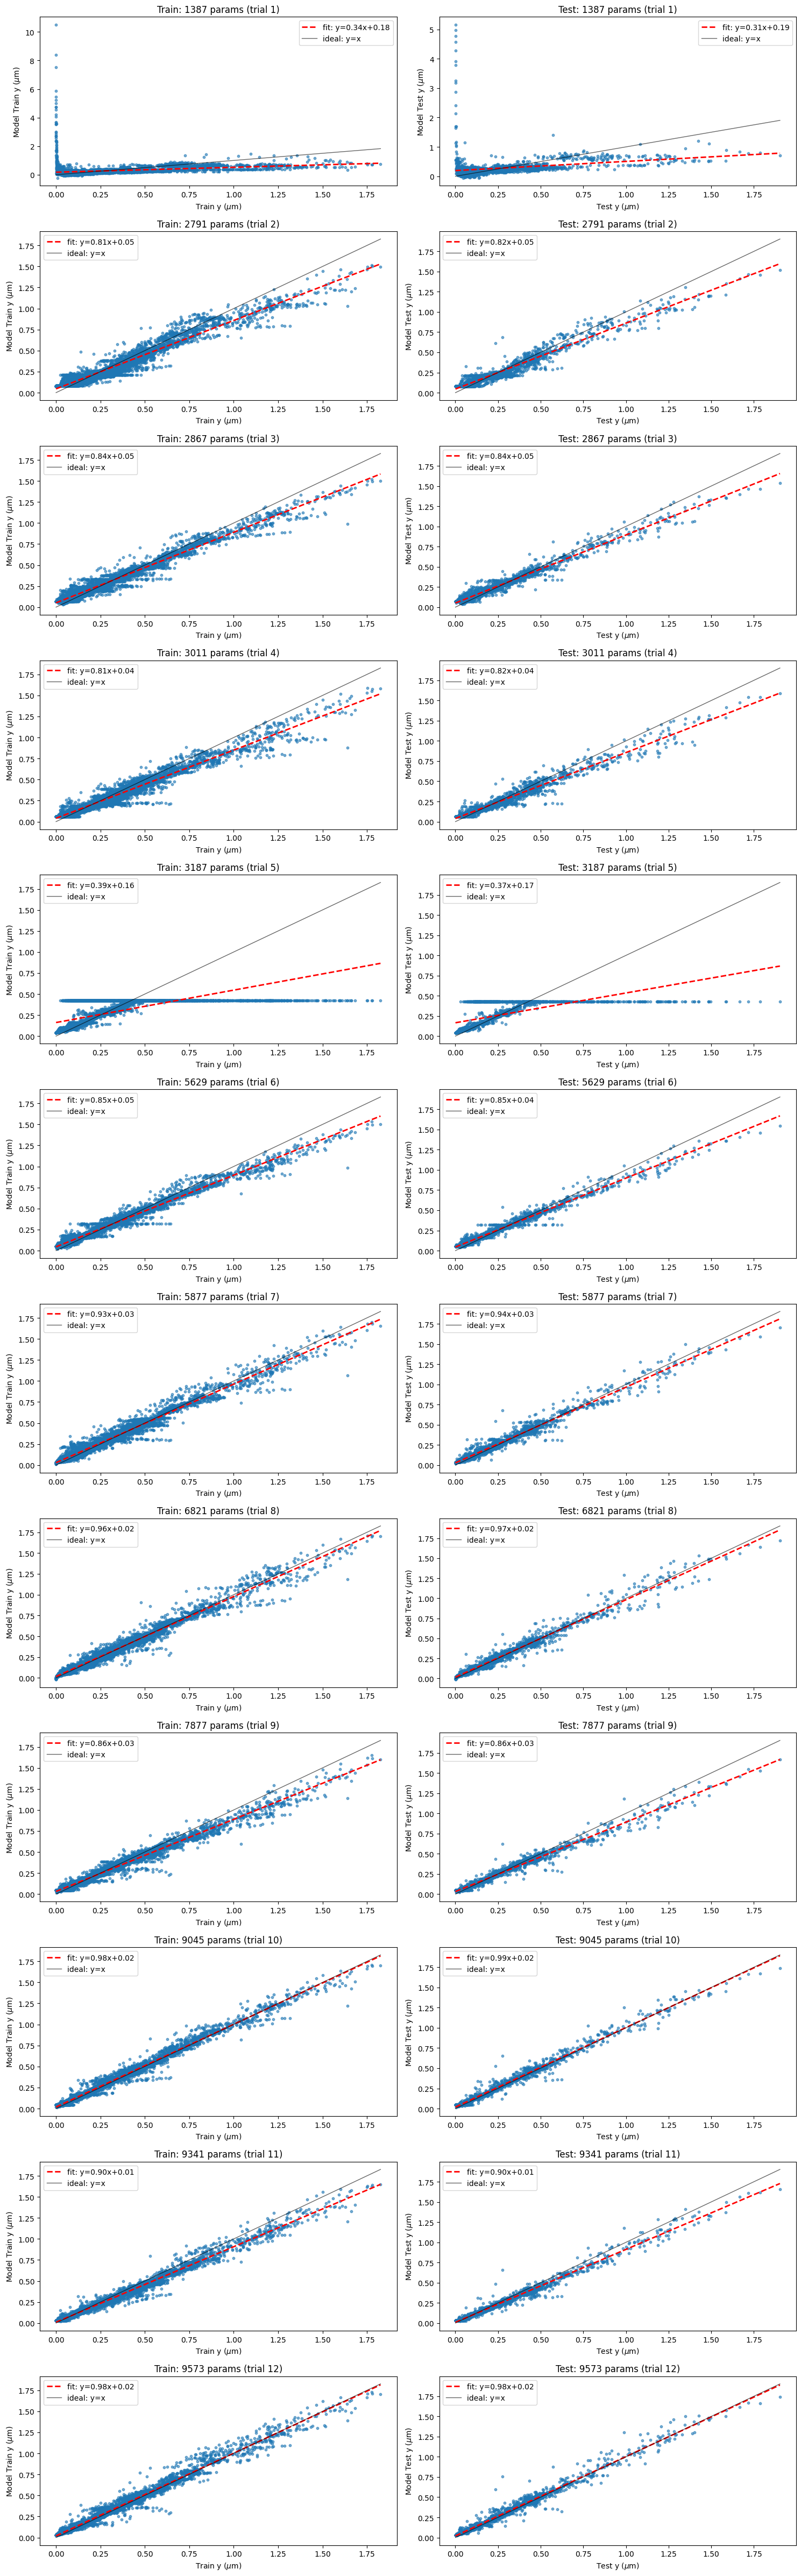

In [8]:
fig, axes = plt.subplots(len(df), 2, figsize=(15, 4*len(df)))
axes = np.atleast_2d(axes)

for i, row in df.reset_index(drop=True).iterrows():
    x_tr = np.asarray(row["train_y"], dtype=float)
    y_tr = np.asarray(row["train_model_y"], dtype=float)
    x_te = np.asarray(row["test_y"], dtype=float)
    y_te = np.asarray(row["test_model_y"], dtype=float)

    plot_scatter_with_fit(axes[i, 0], x_tr, y_tr)
    axes[i, 0].set_title(f'Train: {row["total_parameters"]} params (trial {row["trial_num"]})')
    axes[i, 0].set_xlabel(r"Train y ($\mu$m)")
    axes[i, 0].set_ylabel(r"Model Train y ($\mu$m)")

    plot_scatter_with_fit(axes[i, 1], x_te, y_te)
    axes[i, 1].set_title(f'Test: {row["total_parameters"]} params (trial {row["trial_num"]})')
    axes[i, 1].set_xlabel(r"Test y ($\mu$m)")
    axes[i, 1].set_ylabel(r"Model Test y ($\mu$m)")

plt.tight_layout()
plt.show()